# 01 — Data Understanding (Reconsolidated)

**Project:** Explainable Scenario-Based Simulation of Aircraft Damage Consequences Among Reported Wildlife Strikes Using FAA Data

## Purpose

This notebook examines the raw FAA wildlife-strike data before cleaning or modelling. It combines the notebook audit checklist, the earlier `k_01_data_understanding.ipynb`, the executed consolidated notebook, and the original FAA data dictionary.

It answers four questions:

1. What does the dataset contain?
2. Are the proposed targets and analyses feasible?
3. What data-quality and reporting issues must be addressed during preparation?
4. Which variables may be used as predictors without leaking outcome information?

The project estimates consequences **conditional on a reported wildlife strike**. It does not estimate the chance that an ordinary flight will experience a strike.

This notebook does not overwrite the raw dataset. Decisions that change records or values belong in `02_data_cleaning.ipynb`.


## Source documents used

- `wildlife_strikes_notebook_audit_checklist.docx`: required questions and outputs for Notebook 01.
- `k_01_data_understanding.ipynb`: earlier exploratory work and project context.
- `01_data_understanding_consolidated.ipynb`: executed analysis and saved results used as the numerical basis here.
- `original_data_dictionary(1).xlsx`: FAA field definitions and code tables.

The earlier `k_` notebook includes useful checks, but its project charter, team assignments, and broad planning material are not repeated here because they do not answer the Data Understanding assignment question. Relevant checks were retained or merged into the sections below.


## 1. Setup and data provenance

Update `PROJECT_ROOT`, `DATA_FILE`, or `OFFICIAL_DICTIONARY_FILE` if the repository uses a different layout. The expected layout is:

```text
project/
├── data/
│   ├── raw/
│   └── processed/
├── docs/
│   └── source/
├── notebooks/
└── outputs/
    └── 01_data_understanding/
```

The raw CSV and the original FAA dictionary should remain unchanged. This notebook writes only review artifacts to `outputs/01_data_understanding/` and project-formatted documentation to `docs/`.


In [1]:
from pathlib import Path
import hashlib
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

# Local/Jupyter default: notebook is inside project/notebooks/.
# Change this one line if the notebook is launched from another directory.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()

DATA_FILE = PROJECT_ROOT / "data" / "raw" / "faa_strikes.csv"
OFFICIAL_DICTIONARY_FILE = PROJECT_ROOT / "docs" / "source" / "original_data_dictionary.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "01_data_understanding"
DOCS_DIR = PROJECT_ROOT / "docs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Data file:", DATA_FILE.resolve())
print("Official dictionary:", OFFICIAL_DICTIONARY_FILE.resolve())


Project root: C:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis
Data file: C:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\data\raw\faa_strikes.csv


In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"FAA data file was not found at {DATA_FILE.resolve()}\n"
        "Place the raw CSV there or update DATA_FILE in the setup cell."
    )

# Try UTF-8 first, then fall back to Latin-1 for older exports.
try:
    df = pd.read_csv(DATA_FILE, low_memory=False, encoding="utf-8")
    file_encoding = "utf-8"
except UnicodeDecodeError:
    df = pd.read_csv(DATA_FILE, low_memory=False, encoding="latin-1")
    file_encoding = "latin-1"

file_size_mb = DATA_FILE.stat().st_size / (1024 ** 2)

# A hash helps identify the exact raw file used.
sha256 = hashlib.sha256()
with open(DATA_FILE, "rb") as file:
    for block in iter(lambda: file.read(1024 * 1024), b""):
        sha256.update(block)

provenance = pd.DataFrame({
    "item": [
        "file_name", "file_path", "encoding", "file_size_mb",
        "sha256", "row_count", "column_count"
    ],
    "value": [
        DATA_FILE.name, str(DATA_FILE.resolve()), file_encoding,
        round(file_size_mb, 2), sha256.hexdigest(),
        df.shape[0], df.shape[1]
    ]
})

provenance.to_csv(OUTPUT_DIR / "data_provenance.csv", index=False)
provenance


,item,value
0,file_name,faa_strikes.csv
1,file_path,C:\Users\davis\Programing\MDA_programs\Capston...
2,encoding,latin-1
3,file_size_mb,217.0
4,sha256,6eb926125bf179651613d77f8639f83f06b27e698aef11...
5,row_count,348146
6,column_count,103


## 2. Dataset structure

The structural profile is an inventory, not yet a full data dictionary. Official definitions, units, and valid codes still need to be checked against FAA documentation.


In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())

structural_profile = pd.DataFrame({
    "field": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "non_null_pct": (df.notna().mean().values * 100).round(2),
    "unique_non_null": df.nunique(dropna=True).values,
})

structural_profile.to_csv(OUTPUT_DIR / "structural_profile.csv", index=False)
structural_profile


Rows: 348,146
Columns: 103


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,RUNWAY,STATE,FAAREGION,LOCATION,ENROUTE_STATE,OPID,OPERATOR,REG,FLT,AIRCRAFT,AMA,AMO,EMA,EMO,AC_CLASS,AC_MASS,TYPE_ENG,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,PHASE_OF_FLIGHT,HEIGHT,SPEED,DISTANCE,INCIDENT_LATITUDE,INCIDENT_LONGITUDE,SKY,PRECIPITATION,AOS,COST_REPAIRS,COST_OTHER,COST_REPAIRS_INFL_ADJ,COST_OTHER_INFL_ADJ,INGESTED_OTHER,INDICATED_DAMAGE,DAMAGE_LEVEL,STR_RAD,DAM_RAD,STR_WINDSHLD,DAM_WINDSHLD,STR_NOSE,DAM_NOSE,STR_ENG1,DAM_ENG1,ING_ENG1,STR_ENG2,DAM_ENG2,ING_ENG2,STR_ENG3,DAM_ENG3,ING_ENG3,STR_ENG4,DAM_ENG4,ING_ENG4,STR_PROP,DAM_PROP,STR_WING_ROT,DAM_WING_ROT,STR_FUSE,DAM_FUSE,STR_LG,DAM_LG,STR_TAIL,DAM_TAIL,STR_LGHTS,DAM_LGHTS,STR_OTHER,DAM_OTHER,OTHER_SPECIFY,EFFECT,EFFECT_OTHER,BIRD_BAND_NUMBER,SPECIES_ID,SPECIES,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,NR_INJURIES,NR_FATALITIES,COMMENTS,IMAGE,REPORTED_NAME,REPORTED_TITLE,SOURCE,PERSON,LUPDATE,TRANSFER
0,608242,6/22/1996 0:00:00,6,1996,NaN,NaN,KSMF,SACRAMENTO INTL,NaN,NaN,NaN,CA,AWP,NaN,NaN,UAL,UNITED AIRLINES,NaN,1768,B-737-300,148,24,10.0,1.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Take-off Run,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,UNKBM,Unknown bird - medium,BLOOD ON L FWD NOSE AREA SEEN BY CREW AFTER LDG.,0,0,Unknown,NaN,1,Medium,NaN,NaN,/Legacy Record 100001/,0,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,12/20/2007 0:00:00,0
1,608243,6/26/1996 0:00:00,6,1996,NaN,NaN,KDEN,DENVER INTL AIRPORT,NaN,NaN,NaN,CO,ANM,NaN,NaN,UAL,UNITED AIRLINES,NaN,1845,B-737-300,148,24,10.0,1.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Take-off Run,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,UNKBM,Unknown bird - medium,CREW SUSPECTED BIRDSTRIKE ON T/O. LOOKED LIKE ...,0,0,Unknown,NaN,1,Medium,NaN,NaN,/Legacy Record 100002/,0,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,12/20/2007 0:00:00,0
2,608244,7/1/1996 0:00:00,7,1996,NaN,NaN,KOMA,EPPLEY AIRFIELD,NaN,NaN,NaN,NE,ACE,NaN,NaN,UAL,UNITED AIRLINES,NaN,306,B-757-200,148,26,34.0,40.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Take-off Run,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,N,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,UNKBM,Unknown bird - medium,BIRDSTRIKE AT ROTATION. INSPN. NO DMG.,0,0,Unknown,NaN,1,Medium,NaN,NaN,/Legacy Record 100003/,0,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,12/20/2007 0:00:00,0
3,608245,7/1/1996 0:00:00,7,1996,NaN,NaN,KIAD,WASHINGTON DULLES INTL ARPT,NaN,NaN,NaN,DC,AEA,NaN,NaN,UAL,UNITED AIRLINES,NaN,510,A-320,04A,03,23.0,1.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Approach,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,N,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,UNKBM,Unknown bird - medium,"ON FINAL APCH, STRIKE UNDER THE NOSE OF THE CO...",0,0,Unknown,NaN,1,Medium,NaN,NaN,/Legacy Record 100004/,0,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,12/20/2007 0:00:00,0
4,608246,7/1/1996 0:00:00,7,1996,NaN,NaN,KLGA,LA GUARDIA ARPT,NaN,NaN,NaN,NY,AEA,NaN,NaN,UAL,UNITED AIRLINES,NaN,677,A-320,04A,03,23.0,1.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Climb,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,M,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,UNKBM,Unknown bird - medium,LOUD NOISE WAS HEARD DURING CLIMBOUT THAT SOUN...,0,0,Unknown,NaN,1,Medium,NaN,NaN,/Legacy Record 100005/,0,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,12/20/2007 0:00:00,0


,field,dtype,non_null_count,non_null_pct,unique_non_null
0,INDEX_NR,int64,348146,100.00,348139
1,INCIDENT_DATE,object,348146,100.00,13223
2,INCIDENT_MONTH,int64,348146,100.00,12
3,INCIDENT_YEAR,int64,348146,100.00,37
4,TIME,object,226783,65.14,1441
5,TIME_OF_DAY,object,196417,56.42,4
6,AIRPORT_ID,object,348146,100.00,2779
7,AIRPORT,object,348146,100.00,2779
8,AIRPORT_LATITUDE,float64,0,0.00,0
9,AIRPORT_LONGITUDE,float64,0,0.00,0


**Structure interpretation**

- The file contains 348,146 rows and 103 columns.
- One row is intended to represent one reported wildlife-strike database record, identified by `INDEX_NR`. The repeated-ID review later in this notebook shows that the identifier is not perfectly unique in the current export.
- The dataset mixes identifiers, aircraft information, wildlife information, flight conditions, location, outcomes, costs, and administrative notes. These groups have different roles and should not all be offered to a predictive model.
- The raw coverage extends beyond the approved 1990–2024 analytical period, so the cleaning notebook must apply one shared year rule.


In [4]:
# Numeric summary kept separate because describe(include="all") is difficult to read with 103 fields.
numeric_summary = df.select_dtypes(include=np.number).describe().T
numeric_summary.to_csv(OUTPUT_DIR / "numeric_summary.csv")
numeric_summary


,count,mean,std,min,25%,50%,75%,max
INDEX_NR,348146.0,1.048104e+06,399139.760416,608242.00,707541.25,810386.5,1470809.75,1861554.0
INCIDENT_MONTH,348146.0,7.190753e+00,2.783914,1.00,5.00,8.0,9.00,12.0
INCIDENT_YEAR,348146.0,2.013866e+03,9.056416,1990.00,2008.00,2016.0,2022.00,2026.0
AIRPORT_LATITUDE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AIRPORT_LONGITUDE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EMA,232804.0,1.924030e+01,11.483800,1.00,10.00,22.0,31.00,2207.0
EMO,219635.0,8.108216e+00,11.464982,1.00,1.00,4.0,10.00,97.0
AC_MASS,249686.0,3.561257e+00,0.864454,1.00,3.00,4.0,4.00,5.0
NUM_ENGS,249390.0,2.002667e+00,0.406666,1.00,2.00,2.0,2.00,4.0
ENG_1_POS,249367.0,2.703064e+00,2.115727,1.00,1.00,1.0,5.00,7.0


### Variable families

This list is used to organize the review. It does not decide whether a field is a valid predictor.


In [5]:
def existing(fields):
    return [field for field in fields if field in df.columns]

variable_families = {
    "targets_and_consequences": existing([
        "INDICATED_DAMAGE", "DAMAGE_LEVEL", "EFFECT", "EFFECT_OTHER",
        "AOS", "COST_REPAIRS", "COST_REPAIRS_INFL_ADJ",
        "COST_OTHER", "COST_OTHER_INFL_ADJ",
        "NR_INJURIES", "NR_FATALITIES"
    ]) + [c for c in df.columns if c.startswith("DAM_")],
    "wildlife": existing([
        "SPECIES", "SPECIES_ID", "SIZE", "NUM_SEEN", "NUM_STRUCK",
        "REMAINS_COLLECTED", "REMAINS_SENT", "BIRD_BAND_NUMBER"
    ]),
    "aircraft": existing([
        "AIRCRAFT", "AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS",
        "AMA", "AMO", "EMA", "EMO",
        "ENG_1_POS", "ENG_2_POS", "ENG_3_POS", "ENG_4_POS"
    ]),
    "flight_context": existing([
        "PHASE_OF_FLIGHT", "HEIGHT", "SPEED", "DISTANCE",
        "TIME", "TIME_OF_DAY", "WARNED", "RUNWAY"
    ]),
    "weather": existing(["SKY", "PRECIPITATION"]),
    "geography": existing([
        "AIRPORT_ID", "AIRPORT", "STATE", "FAAREGION",
        "LOCATION", "ENROUTE_STATE",
        "INCIDENT_LATITUDE", "INCIDENT_LONGITUDE",
        "AIRPORT_LATITUDE", "AIRPORT_LONGITUDE"
    ]),
    "time": existing([
        "INCIDENT_DATE", "INCIDENT_MONTH", "INCIDENT_YEAR", "LUPDATE"
    ]),
    "administrative_and_identifiers": existing([
        "INDEX_NR", "OPID", "OPERATOR", "REG", "FLT", "SOURCE",
        "PERSON", "IMAGE", "TRANSFER", "REPORTED_NAME",
        "REPORTED_TITLE", "COMMENTS", "REMARKS"
    ]),
    "strike_and_ingestion_details": (
        [c for c in df.columns if c.startswith("STR_")] +
        [c for c in df.columns if c.startswith("ING_")] +
        existing(["INGESTED_OTHER", "OTHER_SPECIFY"])
    ),
}

family_table = pd.DataFrame([
    {"family": family, "field": field}
    for family, fields in variable_families.items()
    for field in fields
]).drop_duplicates()

unassigned_fields = sorted(set(df.columns) - set(family_table["field"]))
print("Fields not assigned to a review family:", unassigned_fields)
family_table


Fields not assigned to a review family: []


,family,field
0,targets_and_consequences,INDICATED_DAMAGE
1,targets_and_consequences,DAMAGE_LEVEL
2,targets_and_consequences,EFFECT
3,targets_and_consequences,EFFECT_OTHER
4,targets_and_consequences,AOS
5,targets_and_consequences,COST_REPAIRS
6,targets_and_consequences,COST_REPAIRS_INFL_ADJ
7,targets_and_consequences,COST_OTHER
8,targets_and_consequences,COST_OTHER_INFL_ADJ
9,targets_and_consequences,NR_INJURIES


**Review point:** Every raw field should appear in a family. Add genuinely omitted fields to the appropriate list rather than ignoring them.


## 3. Temporal coverage and reporting changes

The proposal uses 1990–2024 as the intended analytical period. This section checks the raw coverage; it does not filter the data.


,INCIDENT_YEAR,INCIDENT_MONTH,INCIDENT_DATE
0,1996,6,6/22/1996 0:00:00
1,1996,6,6/26/1996 0:00:00
2,1996,7,7/1/1996 0:00:00
3,1996,7,7/1/1996 0:00:00
4,1996,7,7/1/1996 0:00:00


Earliest reported year: 1990
Latest reported year: 2026


,record_count,pct_of_records
INCIDENT_YEAR,,
2012,10937,3.14
2013,11406,3.28
2014,13690,3.93
2015,13777,3.96
2016,13379,3.84
2017,14758,4.24
2018,16207,4.66
2019,17348,4.98
2020,11625,3.34


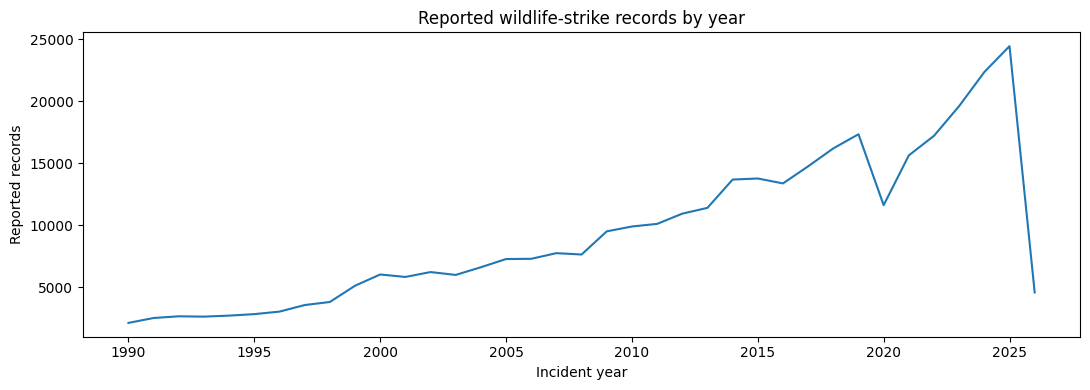

In [6]:
required_time_fields = existing(["INCIDENT_YEAR", "INCIDENT_MONTH", "INCIDENT_DATE"])
display(df[required_time_fields].head())

year_counts = (
    df["INCIDENT_YEAR"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("record_count")
    .to_frame()
)
year_counts["pct_of_records"] = (year_counts["record_count"] / len(df) * 100).round(2)
year_counts.to_csv(OUTPUT_DIR / "records_by_year.csv")

print("Earliest reported year:", df["INCIDENT_YEAR"].min())
print("Latest reported year:", df["INCIDENT_YEAR"].max())
display(year_counts.tail(15))

year_counts["record_count"].plot(
    figsize=(11, 4),
    title="Reported wildlife-strike records by year"
)
plt.xlabel("Incident year")
plt.ylabel("Reported records")
plt.tight_layout()
plt.show()


In [7]:
# Parse dates for validation only. Keep the original INCIDENT_DATE unchanged.
date_text = df["INCIDENT_DATE"].astype("string").str.strip()

parsed_month_first = pd.to_datetime(date_text, errors="coerce", dayfirst=False)
parsed_day_first = pd.to_datetime(date_text, errors="coerce", dayfirst=True)

def consistency_score(parsed):
    score = pd.Series(True, index=df.index)
    if "INCIDENT_YEAR" in df.columns:
        score &= parsed.dt.year.eq(df["INCIDENT_YEAR"])
    if "INCIDENT_MONTH" in df.columns:
        score &= parsed.dt.month.eq(df["INCIDENT_MONTH"])
    return score.fillna(False)

month_first_consistent = consistency_score(parsed_month_first)
day_first_consistent = consistency_score(parsed_day_first)

# Choose row by row only where one interpretation is consistent with the separate year/month fields.
parsed_incident_date = parsed_month_first.copy()
use_day_first = (~month_first_consistent) & day_first_consistent
parsed_incident_date.loc[use_day_first] = parsed_day_first.loc[use_day_first]

date_validation = pd.DataFrame({
    "raw_date": date_text,
    "parsed_date": parsed_incident_date,
    "month_first_consistent": month_first_consistent,
    "day_first_consistent": day_first_consistent,
})
date_validation["unresolved"] = (
    date_validation["parsed_date"].isna() |
    (~date_validation["month_first_consistent"] & ~date_validation["day_first_consistent"])
)

print("Parsed minimum date:", parsed_incident_date.min())
print("Parsed maximum date:", parsed_incident_date.max())
print("Unresolved date rows:", int(date_validation["unresolved"].sum()))

date_validation.loc[date_validation["unresolved"]].head(20)


Parsed minimum date: 1990-01-02 00:00:00
Parsed maximum date: 2026-06-19 00:00:00
Unresolved date rows: 0


C:\Users\davis\AppData\Local\Temp\ipykernel_40548\4013986434.py:5: UserWarning: Parsing dates in %m/%d/%Y %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  parsed_day_first = pd.to_datetime(date_text, errors="coerce", dayfirst=True)


,raw_date,parsed_date,month_first_consistent,day_first_consistent,unresolved


In [8]:
# Coverage and missingness over time can reveal changes in the reporting form or reporting practice.
selected_reporting_fields = existing([
    "SPECIES", "SIZE", "NUM_STRUCK", "PHASE_OF_FLIGHT",
    "HEIGHT", "SPEED", "TIME", "SKY", "WARNED", "DAMAGE_LEVEL"
])

coverage_by_year = (
    df.groupby("INCIDENT_YEAR")[selected_reporting_fields]
      .apply(lambda group: group.notna().mean().mul(100))
      .round(1)
)

coverage_by_year.to_csv(OUTPUT_DIR / "selected_field_coverage_by_year.csv")
coverage_by_year.tail(15)


,SPECIES,SIZE,NUM_STRUCK,PHASE_OF_FLIGHT,HEIGHT,SPEED,TIME,SKY,WARNED,DAMAGE_LEVEL
INCIDENT_YEAR,,,,,,,,,,
2012,100.0,92.7,99.8,60.2,53.9,38.5,56.8,53.6,100.0,63.4
2013,100.0,93.0,99.8,56.2,50.2,35.4,52.8,49.2,100.0,61.8
2014,100.0,87.1,99.8,59.2,48.8,30.4,55.9,43.9,100.0,63.6
2015,100.0,88.7,99.9,57.9,47.7,29.7,52.0,45.1,100.0,64.4
2016,100.0,85.3,99.8,57.8,45.6,25.1,64.1,46.0,100.0,61.8
2017,100.0,87.6,99.9,54.0,41.1,22.6,59.2,42.1,100.0,55.0
2018,100.0,86.9,99.8,55.9,42.6,25.4,56.8,39.9,100.0,57.8
2019,100.0,84.8,99.8,54.7,42.2,23.7,83.7,39.3,100.0,56.9
2020,100.0,85.5,99.8,52.3,41.2,22.8,92.8,39.1,100.0,50.7


**Interpretation of the time results**

- The raw file covers 1990 through June 19, 2026. The 2026 count is therefore incomplete and should not be compared with complete years.
- The proposed 1990–2024 period is a defensible complete-year window. The file also contains a complete 2025 year, but adding it should be a documented team decision so that every notebook uses the same cutoff.
- Report volume generally rises over time, with 22,371 records in 2024 and 24,459 in 2025. This does not prove that wildlife strikes became more likely because the dataset has no denominator for ordinary flights and reporting practices changed over time.
- Field coverage also changes. For example, `TIME` becomes much more complete in recent years, while `SIZE`, `HEIGHT`, `SPEED`, and `SKY` remain incomplete or decline in coverage. Year may therefore capture reporting-system changes as well as real differences.
- The date parser found no unresolved rows when checked against the separate year and month fields.


## 4. Primary and secondary outcomes

The primary question is whether damage was reported among recorded strikes. Severity and component damage are separate outcomes and must not be used as predictors of the binary damage target.


In [9]:
PRIMARY_TARGET = "INDICATED_DAMAGE"

target_summary = (
    df[PRIMARY_TARGET]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)
target_summary["percentage"] = (
    target_summary["count"] / len(df) * 100
).round(2)

majority_accuracy = target_summary["count"].max() / len(df)

print(f"Majority-class benchmark accuracy: {majority_accuracy:.4f}")
target_summary


Majority-class benchmark accuracy: 0.9367


,count,percentage
INDICATED_DAMAGE,,
0,326100,93.67
1,22046,6.33


In [10]:
# Severity is interpreted among damaged incidents.
damaged = df.loc[df["INDICATED_DAMAGE"] == 1].copy()

severity_overall = (
    df["DAMAGE_LEVEL"].value_counts(dropna=False)
      .rename("count").to_frame()
)
severity_overall["percentage_all_records"] = (
    severity_overall["count"] / len(df) * 100
).round(3)

severity_damaged = (
    damaged["DAMAGE_LEVEL"].value_counts(dropna=False)
           .rename("count").to_frame()
)
severity_damaged["percentage_among_damaged"] = (
    severity_damaged["count"] / len(damaged) * 100
).round(3)

consistency_table = pd.crosstab(
    df["INDICATED_DAMAGE"],
    df["DAMAGE_LEVEL"],
    dropna=False
)

display(severity_overall)
display(severity_damaged)
display(consistency_table)


,count,percentage_all_records
DAMAGE_LEVEL,,
N,203496,58.451
NaN,122605,35.217
M,8783,2.523
M?,8772,2.520
S,4401,1.264
D,89,0.026


,count,percentage_among_damaged
DAMAGE_LEVEL,,
M,8783,39.839
M?,8770,39.780
S,4401,19.963
D,89,0.404
N,3,0.014


DAMAGE_LEVEL,D,M,M?,N,S,NaN
INDICATED_DAMAGE,,,,,,
0,0,0,2,203493,0,122605
1,89,8783,8770,3,4401,0


**Interpretation and manual decisions for severity**

- `INDICATED_DAMAGE` is the primary target. Damage is reported in 22,046 records (6.33%), while 326,100 records (93.67%) report no damage. A model that always predicts no damage would reach 93.67% accuracy, so later modelling must use imbalance-aware measures rather than accuracy alone.
- Among damaged records, minor (`M`) and undetermined (`M?`) each account for about 40%, substantial (`S`) accounts for about 20%, and destroyed (`D`) is very rare with 89 cases.
- Five target combinations are inconsistent: three damaged records have `DAMAGE_LEVEL = N`, and two non-damaged records have `DAMAGE_LEVEL = M?`. Notebook 02 must flag and resolve these using a documented rule.
- The FAA dictionary defines `N`, `M`, `M?`, `S`, and `D`; these definitions should be copied into the project-formatted data dictionary.
- Whether `M` and `M?` should be kept separate is a manual modelling decision. They should not be merged only because their counts are similar.


In [11]:
component_fields = [c for c in df.columns if c.startswith("DAM_")]

component_rows = []
for field in component_fields:
    values = df[field]
    component_rows.append({
        "field": field,
        "positive_1": int(values.eq(1).sum()),
        "negative_0": int(values.eq(0).sum()),
        "missing": int(values.isna().sum()),
        "other_values": int((~values.isin([0, 1]) & values.notna()).sum()),
        "positive_rate_all_records_pct": round(values.eq(1).mean() * 100, 4),
        "positive_rate_damaged_records_pct": round(
            df.loc[df["INDICATED_DAMAGE"].eq(1), field].eq(1).mean() * 100, 4
        ),
        "feasibility_decision": "Pending review",
    })

component_feasibility = (
    pd.DataFrame(component_rows)
      .sort_values("positive_1", ascending=False)
)

component_feasibility.to_csv(
    OUTPUT_DIR / "component_outcome_feasibility.csv", index=False
)
component_feasibility


,field,positive_1,negative_0,missing,other_values,positive_rate_all_records_pct,positive_rate_damaged_records_pct,feasibility_decision
8,DAM_WING_ROT,6693,341453,0,0,1.9225,30.3592,Pending review
3,DAM_ENG1,3210,344936,0,0,0.9220,14.5605,Pending review
4,DAM_ENG2,2736,345410,0,0,0.7859,12.4104,Pending review
13,DAM_OTHER,2582,345564,0,0,0.7416,11.7119,Pending review
0,DAM_RAD,2204,345942,0,0,0.6331,9.9973,Pending review
2,DAM_NOSE,1868,346278,0,0,0.5366,8.4732,Pending review
1,DAM_WINDSHLD,1547,346599,0,0,0.4444,7.0171,Pending review
10,DAM_LG,1363,346783,0,0,0.3915,6.1825,Pending review
9,DAM_FUSE,1256,346890,0,0,0.3608,5.6972,Pending review
11,DAM_TAIL,1095,347051,0,0,0.3145,4.9669,Pending review


**Component-outcome interpretation**

- All 14 `DAM_*` fields are stored as complete binary indicators, but their positive classes are uneven.
- Wing/rotor damage has the strongest support (6,693 positive records). Engine 1, Engine 2, other, radome, and nose damage also have more than 1,800 positives.
- Engine 3 and Engine 4 damage are very rare (169 and 68 positives). They should remain descriptive unless later validation shows that reliable models are possible.
- Final labels of `model`, `descriptive only`, or `exclude` still require manual review because sample size alone does not establish reliable probability estimates.


## 5. Wildlife variables

This section should make the basic content of the wildlife fields understandable before any grouping is attempted.


In [12]:
def categorical_profile(data, field, top_n=20):
    counts = data[field].value_counts(dropna=False)
    result = counts.rename("count").to_frame()
    result["percentage"] = (result["count"] / len(data) * 100).round(3)
    return result.head(top_n)

for field in existing(["SPECIES", "SPECIES_ID", "SIZE", "NUM_SEEN", "NUM_STRUCK"]):
    print(f"\n{field}: {df[field].nunique(dropna=True):,} non-null unique values")
    display(categorical_profile(df, field, top_n=25))



SPECIES: 973 non-null unique values


,count,percentage
SPECIES,,
Unknown bird - small,55183,15.851
Unknown bird - medium,39473,11.338
Unknown bird,38885,11.169
Mourning dove,18160,5.216
Barn swallow,11761,3.378
Killdeer,11509,3.306
American kestrel,10582,3.040
Horned lark,10061,2.890
Gulls,7696,2.211



SPECIES_ID: 972 non-null unique values


,count,percentage
SPECIES_ID,,
UNKBS,55183,15.851
UNKBM,39473,11.338
UNKB,38885,11.169
O2205,18160,5.216
YI005,11761,3.378
N5111,11509,3.306
K5114,10582,3.040
YH004,10061,2.890
NE1,7696,2.211



SIZE: 3 non-null unique values


,count,percentage
SIZE,,
Small,214313,61.558
Medium,73623,21.147
NaN,39365,11.307
Large,20845,5.987



NUM_SEEN: 4 non-null unique values


,count,percentage
NUM_SEEN,,
NaN,236515,67.936
1,68422,19.653
2-10,33984,9.761
11-100,8132,2.336
More than 100,1093,0.314



NUM_STRUCK: 4 non-null unique values


,count,percentage
NUM_STRUCK,,
1,309989,89.040
2-10,35688,10.251
11-100,1667,0.479
NaN,743,0.213
More than 100,59,0.017


In [13]:
species_counts = (
    df["SPECIES"]
    .value_counts(dropna=False)
    .rename("reported_strikes")
    .to_frame()
)
species_counts["share_pct"] = (
    species_counts["reported_strikes"] / len(df) * 100
).round(3)

print("Most frequently reported SPECIES label:")
display(species_counts.head(1))
display(species_counts.head(25))

species_counts.head(50).to_csv(OUTPUT_DIR / "top_species_labels.csv")


Most frequently reported SPECIES label:


,reported_strikes,share_pct
SPECIES,,
Unknown bird - small,55183,15.851


,reported_strikes,share_pct
SPECIES,,
Unknown bird - small,55183,15.851
Unknown bird - medium,39473,11.338
Unknown bird,38885,11.169
Mourning dove,18160,5.216
Barn swallow,11761,3.378
Killdeer,11509,3.306
American kestrel,10582,3.040
Horned lark,10061,2.890
Gulls,7696,2.211


In [14]:
# Inspect whether species labels and IDs map consistently.
if {"SPECIES", "SPECIES_ID"}.issubset(df.columns):
    species_id_map = (
        df.groupby("SPECIES", dropna=False)["SPECIES_ID"]
          .agg(
              record_count="size",
              unique_species_ids=lambda x: x.nunique(dropna=True),
              example_species_ids=lambda x: sorted(x.dropna().astype(str).unique())[:5]
          )
          .sort_values(["unique_species_ids", "record_count"], ascending=[False, False])
    )
    display(species_id_map.head(30))


,record_count,unique_species_ids,example_species_ids
SPECIES,,,
Unknown bird - small,55183,1,[UNKBS]
Unknown bird - medium,39473,1,[UNKBM]
Unknown bird,38885,1,[UNKB]
Mourning dove,18160,1,[O2205]
Barn swallow,11761,1,[YI005]
Killdeer,11509,1,[N5111]
American kestrel,10582,1,[K5114]
Horned lark,10061,1,[YH004]
Gulls,7696,1,[NE1]


In [15]:
# Damage counts and rates answer different questions; show both with sample size.
species_damage = (
    df.groupby("SPECIES", dropna=False)["INDICATED_DAMAGE"]
      .agg(reported_strikes="size", damaging_strikes="sum", damage_rate="mean")
      .reset_index()
)
species_damage["damage_rate_pct"] = (species_damage["damage_rate"] * 100).round(2)

print("Species labels with the largest number of damaging records:")
display(
    species_damage.sort_values("damaging_strikes", ascending=False).head(20)
)

MIN_SPECIES_RECORDS_FOR_RATE_DISPLAY = 100
print(f"Highest observed damage rates among labels with at least {MIN_SPECIES_RECORDS_FOR_RATE_DISPLAY} records:")
display(
    species_damage.loc[
        species_damage["reported_strikes"] >= MIN_SPECIES_RECORDS_FOR_RATE_DISPLAY
    ].sort_values("damage_rate", ascending=False).head(20)
)


Species labels with the largest number of damaging records:


,SPECIES,reported_strikes,damaging_strikes,damage_rate,damage_rate_pct
851,Unknown bird - medium,39473,4617,0.116966,11.70
849,Unknown bird,38885,1694,0.043564,4.36
850,Unknown bird - large,4023,1472,0.365896,36.59
852,Unknown bird - small,55183,1426,0.025841,2.58
395,Gulls,7696,1167,0.151637,15.16
917,White-tailed deer,1390,1135,0.816547,81.65
162,Canada goose,2325,1065,0.458065,45.81
845,Turkey vulture,1365,637,0.466667,46.67
698,Red-tailed hawk,4581,581,0.126828,12.68
409,Hawks,1758,337,0.191695,19.17


Highest observed damage rates among labels with at least 100 records:


,SPECIES,reported_strikes,damaging_strikes,damage_rate,damage_rate_pct
917,White-tailed deer,1390,1135,0.816547,81.65
774,Snow goose,211,137,0.649289,64.93
78,Black vulture,442,282,0.638009,63.80
383,Greater white-fronted goose,119,68,0.571429,57.14
561,New World vultures,436,248,0.568807,56.88
339,Geese,502,261,0.519920,51.99
269,"Ducks, geese, swans",154,75,0.487013,48.70
845,Turkey vulture,1365,637,0.466667,46.67
162,Canada goose,2325,1065,0.458065,45.81
583,Northern pintail,325,141,0.433846,43.38


**Interpretation of wildlife fields**

- The dataset contains 973 non-null `SPECIES` labels and 972 non-null `SPECIES_ID` values, so exact species is a high-cardinality field.
- `Unknown bird - small` is the most frequent label with 55,183 records (15.85%). Together, unknown small, medium, unspecified, and large bird categories account for a large part of the dataset.
- A common label is not the same as a high-damage label. For example, `Unknown bird - small` is frequent but has a 2.58% observed damage rate, while larger wildlife categories show higher conditional damage rates.
- White-tailed deer has the highest displayed damage rate among labels with at least 100 records (81.65%), but this is the damage proportion among reported strikes involving that label. It is not the chance that an ordinary flight will strike a deer.
- `SPECIES` and `SPECIES_ID` usually map together in the most common groups, but broader and more specific labels, synonyms, spelling, and taxonomy still need review. Broad wildlife groups will probably be more stable for modelling, while exact labels can remain useful for description and historical-support warnings.


## 6. Aircraft, flight context, weather, and geography

These summaries identify common categories, sparsity, and potentially implausible numerical values. Cleaning decisions remain for Notebook 02.


In [16]:
for field in existing([
    "AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS",
    "PHASE_OF_FLIGHT", "WARNED", "TIME_OF_DAY",
    "SKY", "PRECIPITATION", "FAAREGION", "STATE"
]):
    print(f"\n### {field}")
    display(categorical_profile(df, field, top_n=25))



### AC_CLASS


,count,percentage
AC_CLASS,,
A,244413,70.204
NaN,98325,28.242
B,5394,1.549
C,7,0.002
J,4,0.001
Y,3,0.001



### AC_MASS


,count,percentage
AC_MASS,,
4.0,179386,51.526
NaN,98460,28.281
3.0,37482,10.766
2.0,15140,4.349
1.0,14866,4.270
5.0,2812,0.808



### TYPE_ENG


...

,count,percentage
PRECIPITATION,,
NaN,335510,96.370
Rain,8798,2.527
Fog,2749,0.790
Snow,637,0.183
"Fog, Rain",358,0.103
"Rain, Snow",31,0.009
"Fog, Snow",20,0.006
"None, Snow",18,0.005
"None, Rain",13,0.004



### FAAREGION


,count,percentage
FAAREGION,,
ASO,66053,18.973
NaN,46930,13.480
AGL,46638,13.396
AEA,46149,13.256
ASW,41404,11.893
AWP,36896,10.598
ANM,31728,9.113
ACE,13883,3.988
ANE,11005,3.161



### STATE


,count,percentage
STATE,,
NaN,46930,13.480
TX,31234,8.972
FL,25552,7.339
CA,24593,7.064
NY,16258,4.670
CO,15137,4.348
IL,13937,4.003
TN,10609,3.047
OH,9185,2.638


In [17]:
for field in existing(["HEIGHT", "SPEED", "DISTANCE", "NUM_ENGS", "INCIDENT_MONTH", "INCIDENT_YEAR"]):
    print(f"\n### {field}")
    display(df[field].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame().T)

# Show the most extreme non-null values for manual plausibility review.
for field in existing(["HEIGHT", "SPEED", "DISTANCE"]):
    print(f"\nLowest {field} values")
    display(df[[field]].dropna().nsmallest(10, field))
    print(f"Highest {field} values")
    display(df[[field]].dropna().nlargest(10, field))



### HEIGHT


,count,mean,std,min,1%,5%,50%,95%,99%,max
HEIGHT,172981.0,883.587683,1859.838808,0.0,0.0,0.0,50.0,4700.0,9000.0,40000.0



### SPEED


,count,mean,std,min,1%,5%,50%,95%,99%,max
SPEED,107648.0,143.071269,46.509428,0.0,45.0,70.0,140.0,250.0,250.0,541.0



### DISTANCE


...

,SPEED
262917,541.0
204178,400.0
300312,400.0
338340,400.0
346948,400.0
85213,380.0
99557,374.0
153761,363.0
87350,355.0
88502,355.0



Lowest DISTANCE values


,DISTANCE
0,0.0
1,0.0
2,0.0
5,0.0
6,0.0
8,0.0
9,0.0
11,0.0
13,0.0
14,0.0


Highest DISTANCE values


,DISTANCE
192398,99.0
266166,99.0
293653,99.0
305448,99.0
316588,99.0
340039,99.0
341952,99.0
1180,95.0
140399,90.0
244857,90.0


In [18]:
for field in existing(["AIRPORT_ID", "AIRPORT", "OPERATOR", "AIRCRAFT"]):
    print(f"\n{field}: {df[field].nunique(dropna=True):,} non-null unique values")
    display(categorical_profile(df, field, top_n=20))



AIRPORT_ID: 2,779 non-null unique values


,count,percentage
AIRPORT_ID,,
ZZZZ,46853,13.458
KDEN,11642,3.344
KDFW,9005,2.587
KORD,7350,2.111
KJFK,6706,1.926
KMEM,5528,1.588
KSLC,4394,1.262
KATL,4358,1.252
KSMF,4339,1.246



AIRPORT: 2,779 non-null unique values


,count,percentage
AIRPORT,,
UNKNOWN,46853,13.458
DENVER INTL AIRPORT,11642,3.344
DALLAS/FORT WORTH INTL ARPT,9005,2.587
CHICAGO O'HARE INTL ARPT,7350,2.111
JOHN F KENNEDY INTL,6706,1.926
MEMPHIS INTL,5528,1.588
SALT LAKE CITY INTL,4394,1.262
HARTSFIELD - JACKSON ATLANTA INTL ARPT,4358,1.252
SACRAMENTO INTL,4339,1.246



OPERATOR: 625 non-null unique values


,count,percentage
OPERATOR,,
UNKNOWN,97581,28.029
SOUTHWEST AIRLINES,32349,9.292
BUSINESS,28972,8.322
AMERICAN AIRLINES,25432,7.305
UNITED AIRLINES,20608,5.919
DELTA AIR LINES,17037,4.894
FEDEX EXPRESS,10698,3.073
SKYWEST AIRLINES,8542,2.454
UPS AIRLINES,6890,1.979



AIRCRAFT: 636 non-null unique values


,count,percentage
AIRCRAFT,,
UNKNOWN,97883,28.116
A-320,17251,4.955
B-737-800,14978,4.302
B-737-700,12997,3.733
EMB-170,12428,3.570
A-319,10380,2.982
CRJ100/200,9925,2.851
B-737-300,9353,2.687
B-757-200,8903,2.557


**Interpretation of aircraft, flight, weather, and geography results**

- The data contain many aircraft and airport categories, including large `UNKNOWN` groups. Unknown aircraft and operators each account for about 28% of records, so these values cannot be treated as ordinary categories without discussion.
- `ZZZZ` / `UNKNOWN` is the most frequent airport entry with 46,853 records (13.46%). Denver International is the most common **named** airport with 11,642 records (3.34%). Denver is not a majority of the dataset; the records are spread across many airports.
- Airport counts show where reports are concentrated, not where a normal flight is most likely to experience a strike. Flight-volume denominators would be required for that claim.
- Numerical checks found values that need range rules, such as speeds up to 541 knots and distance values repeatedly coded as 99 nautical miles. These may be valid, capped, or sentinel values and must be checked before cleaning.
- Airport IDs and airport names should be tested as pairs. Aircraft class, mass, engine type, number of engines, and engine positions also need cross-field consistency checks using the official code tables.


## 7. Missingness and reporting completeness

Ordinary `isna()` counts do not capture blank strings or textual unknown categories. This section reports them separately without deciding that every “unknown” value is equivalent.


In [19]:
COMMON_SENTINELS = {
    "UNKNOWN", "UNK", "NOT REPORTED", "NOT REPORTED/UNKNOWN",
    "UNSPECIFIED", "N/A", "NA"
}

def missing_like_profile(series):
    true_null = series.isna()
    blank = pd.Series(False, index=series.index)
    sentinel = pd.Series(False, index=series.index)

    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        text = series.astype("string")
        stripped = text.str.strip()
        blank = stripped.eq("").fillna(False)
        sentinel = stripped.str.upper().isin(COMMON_SENTINELS).fillna(False)

    return {
        "true_null": int(true_null.sum()),
        "blank_string": int(blank.sum()),
        "common_unknown_label": int(sentinel.sum()),
        "missing_like_total": int((true_null | blank | sentinel).sum()),
    }

missing_rows = []
for field in df.columns:
    row = {"field": field, **missing_like_profile(df[field])}
    row["missing_like_pct"] = round(row["missing_like_total"] / len(df) * 100, 2)
    missing_rows.append(row)

missingness = (
    pd.DataFrame(missing_rows)
      .sort_values("missing_like_pct", ascending=False)
)

missingness.to_csv(OUTPUT_DIR / "expanded_missingness.csv", index=False)
missingness.head(30)


,field,true_null,blank_string,common_unknown_label,missing_like_total,missing_like_pct
37,INCIDENT_LONGITUDE,348146,0,0,348146,100.00
9,AIRPORT_LONGITUDE,348146,0,0,348146,100.00
8,AIRPORT_LATITUDE,348146,0,0,348146,100.00
36,INCIDENT_LATITUDE,348146,0,0,348146,100.00
94,NR_FATALITIES,348121,0,0,348121,99.99
93,NR_INJURIES,347844,0,0,347844,99.91
83,BIRD_BAND_NUMBER,347352,0,0,347352,99.77
82,EFFECT_OTHER,345363,0,0,345363,99.20
31,ENG_4_POS,344505,0,0,344505,98.95
43,COST_REPAIRS_INFL_ADJ,342721,0,0,342721,98.44


In [20]:
selected_missingness_fields = existing([
    "SPECIES", "SIZE", "NUM_STRUCK", "PHASE_OF_FLIGHT",
    "HEIGHT", "SPEED", "TIME", "SKY", "WARNED", "DAMAGE_LEVEL"
])

missingness_by_damage = (
    df.groupby("INDICATED_DAMAGE")[selected_missingness_fields]
      .apply(lambda group: group.isna().mean().mul(100))
      .round(1)
)
missingness_by_damage.to_csv(OUTPUT_DIR / "missingness_by_damage.csv")

display(missingness_by_damage)


,SPECIES,SIZE,NUM_STRUCK,PHASE_OF_FLIGHT,HEIGHT,SPEED,TIME,SKY,WARNED,DAMAGE_LEVEL
INDICATED_DAMAGE,,,,,,,,,,
0,0.0,11.5,0.2,41.3,52.0,70.8,34.8,54.7,0.0,37.6
1,0.0,7.8,0.6,12.0,24.7,44.3,35.2,30.4,0.0,0.0


**Interpretation of missingness**

- Missingness is not uniform. `SPEED` is missing in about 69% of all records, `NUM_SEEN` in about 68%, `SKY` in about 53%, and `HEIGHT` in about 50%.
- Some fields look complete under `isna()` but contain textual unknown values. `WARNED`, for example, has no nulls but 216,877 records (62.29%) are coded as `Unknown`.
- Damaged incidents are documented more completely for several fields. Phase of flight is missing in 12.0% of damaged records versus 41.3% of non-damaged records; height is missing in 24.7% versus 52.0%; speed is missing in 44.3% versus 70.8%; and sky is missing in 30.4% versus 54.7%.
- This difference may create reporting bias. Missingness indicators may be useful, but their use must be decided inside the approved feature table.
- Blank, unknown, not reported, not applicable, and historically unavailable values must remain distinct until their meanings are confirmed. Blank injuries or fatalities must not automatically become zero.


## 8. Duplicate and consistency review


In [21]:
exact_duplicate_rows = int(df.duplicated().sum())

id_counts = df["INDEX_NR"].value_counts(dropna=False)
repeated_ids = id_counts[id_counts > 1]

repeated_records = (
    df.loc[df["INDEX_NR"].isin(repeated_ids.index)]
      .sort_values("INDEX_NR")
)

print("Exact duplicate rows:", exact_duplicate_rows)
print("Repeated INDEX_NR groups:", len(repeated_ids))
display(repeated_ids)
display(repeated_records)

difference_rows = []
for incident_id, group in repeated_records.groupby("INDEX_NR", dropna=False):
    differing_fields = [
        field for field in df.columns
        if group[field].nunique(dropna=False) > 1
    ]
    difference_rows.append({
        "INDEX_NR": incident_id,
        "rows": len(group),
        "differing_fields": ", ".join(differing_fields),
    })

duplicate_differences = pd.DataFrame(difference_rows)
duplicate_differences.to_csv(OUTPUT_DIR / "repeated_id_review.csv", index=False)
duplicate_differences


Exact duplicate rows: 0
Repeated INDEX_NR groups: 7


INDEX_NR
778860     2
793166     2
814615     2
1520761    2
1850036    2
1850863    2
1859904    2
Name: count, dtype: int64

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,RUNWAY,STATE,FAAREGION,LOCATION,ENROUTE_STATE,OPID,OPERATOR,REG,FLT,AIRCRAFT,AMA,AMO,EMA,EMO,AC_CLASS,AC_MASS,TYPE_ENG,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,PHASE_OF_FLIGHT,HEIGHT,SPEED,DISTANCE,INCIDENT_LATITUDE,INCIDENT_LONGITUDE,SKY,PRECIPITATION,AOS,COST_REPAIRS,COST_OTHER,COST_REPAIRS_INFL_ADJ,COST_OTHER_INFL_ADJ,INGESTED_OTHER,INDICATED_DAMAGE,DAMAGE_LEVEL,STR_RAD,DAM_RAD,STR_WINDSHLD,DAM_WINDSHLD,STR_NOSE,DAM_NOSE,STR_ENG1,DAM_ENG1,ING_ENG1,STR_ENG2,DAM_ENG2,ING_ENG2,STR_ENG3,DAM_ENG3,ING_ENG3,STR_ENG4,DAM_ENG4,ING_ENG4,STR_PROP,DAM_PROP,STR_WING_ROT,DAM_WING_ROT,STR_FUSE,DAM_FUSE,STR_LG,DAM_LG,STR_TAIL,DAM_TAIL,STR_LGHTS,DAM_LGHTS,STR_OTHER,DAM_OTHER,OTHER_SPECIFY,EFFECT,EFFECT_OTHER,BIRD_BAND_NUMBER,SPECIES_ID,SPECIES,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,NR_INJURIES,NR_FATALITIES,COMMENTS,IMAGE,REPORTED_NAME,REPORTED_TITLE,SOURCE,PERSON,LUPDATE,TRANSFER
152380,778860,3/1/2016 0:00:00,3,2016,NaN,NaN,KPSM,PORTSMOUTH INTL ARPT AT PEASE,NaN,NaN,16,NH,ANE,NaN,NaN,UNK,UNKNOWN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,1E33,Squirrels,2030 NIGHT.,1,0,Unknown,NaN,1,Medium,NaN,NaN,2016-3-1-211917 /Legacy Record 371717/,0,REDACTED,REDACTED,FAA Form 5200-7-E,Carcass Found,9/1/2016 0:00:00,0
152381,778860,3/1/2016 0:00:00,3,2016,NaN,NaN,KPSM,PORTSMOUTH INTL ARPT AT PEASE,NaN,NaN,16,NH,ANE,NaN,NaN,UNK,UNKNOWN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,1E33,Tree squirrels,2030 NIGHT.,1,0,Unknown,NaN,1,Medium,NaN,NaN,2016-3-1-211917 /Legacy Record 371717/,0,REDACTED,REDACTED,FAA Form 5200-7-E,Carcass Found,9/1/2016 0:00:00,0
162301,793166,4/29/2017 0:00:00,4,2017,NaN,NaN,KNUQ,MOFFETT FEDERAL AIRFIELD,NaN,NaN,32R,CA,AWP,NaN,NaN,UNK,UNKNOWN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,1E33,Squirrels,Found during,1,0,Unknown,NaN,1,Medium,NaN,NaN,2017-6-12-173440 /Legacy Record 390497/,0,REDACTED,REDACTED,FAA Form 5200-7-E,Carcass Found,5/18/2018 0:00:00,0
162302,793166,4/29/2017 0:00:00,4,2017,NaN,NaN,KNUQ,MOFFETT FEDERAL AIRFIELD,NaN,NaN,32R,CA,AWP,NaN,NaN,UNK,UNKNOWN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,1E33,Tree squirrels,Found during,1,0,Unknown,NaN,1,Medium,NaN,NaN,2017-6-12-173440 /Legacy Record 390497/,0,REDACTED,REDACTED,FAA Form 5200-7-E,Carcass Found,5/18/2018 0:00:00,0
177357,814615,9/27/2018 0:00:00,9,2018,NaN,NaN,KBDL,BRADLEY INTL,NaN,NaN,6,CT,ANE,NaN,NaN,UNK,UNKNOWN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,1E33,Squirrels,Tower informed to Airport Operation of possibl...,1,0,Unknown,NaN,1,Medium,NaN,NaN,2018-9-28-111208 /Legacy Record 416060/,0,REDACTED,REDACTED,FAA Form 5200-7-E,Carcass Found,11/27/2018 0:00:00,0
177358,814615,9/27/2018 0:00:00,9,2018,NaN,NaN,KBDL,BRADLEY INTL,NaN,NaN,6,CT,ANE,NaN,NaN,UNK,UNKNOWN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,1E33,Tree squirrels,Tower informed to Airport Operation of possibl...,1,0,Unknown,NaN,1,Medium,NaN,NaN,2018-9-28-111208 /Legacy Record 416060/,0,REDACT

,INDEX_NR,rows,differing_fields
0,778860,2,SPECIES
1,793166,2,SPECIES
2,814615,2,SPECIES
3,1520761,2,SPECIES
4,1850036,2,SPECIES
5,1850863,2,SPECIES
6,1859904,2,SPECIES


**Duplicate and repeated-identifier decision**

- No exact full-row duplicates were found.
- Seven `INDEX_NR` values appear twice. In each pair, `SPECIES` is the reported differing field, often using a broad label beside a more specific label.
- These rows should remain flagged rather than automatically deleted. They may represent duplicate incidents, revised classifications, or two valid database rows. Notebook 02 needs a documented rule based on source meaning, not only row similarity.


## 9. Draft data dictionary

This export combines structural evidence from the dataset with fields that require human documentation. Fill the blank columns from the official FAA source before treating it as final.


In [ ]:
# Build the project-formatted dictionary from the raw structural profile and
# the unchanged FAA source dictionary.
data_dictionary = structural_profile.copy()

# The exported CSV uses a few clearer names than the original FAA workbook.
OFFICIAL_NAME_ALIASES = {
    "INDEX NR": "INDEX_NR",
    "ATYPE": "AIRCRAFT",
    "DAMAGE": "DAMAGE_LEVEL",
    "BIRDS_SEEN": "NUM_SEEN",
    "BIRDS_STRUCK": "NUM_STRUCK",
    "PHASE_OF_FLT": "PHASE_OF_FLIGHT",
    "PRECIP": "PRECIPITATION",
    "ENROUTE": "ENROUTE_STATE",
}

if OFFICIAL_DICTIONARY_FILE.exists():
    official = pd.read_excel(
        OFFICIAL_DICTIONARY_FILE,
        sheet_name="Column Name",
        usecols=[0, 1],
        header=0,
    )
    official.columns = ["official_field", "official_definition"]
    official = official.dropna(subset=["official_field"]).copy()
    official["official_field"] = official["official_field"].astype(str).str.strip()

    # Rows such as "N = None" explain DAMAGE_LEVEL codes rather than fields.
    official_fields = official[official["official_field"].isin(set(OFFICIAL_NAME_ALIASES) | set(df.columns))].copy()
    official_fields["field"] = official_fields["official_field"].replace(OFFICIAL_NAME_ALIASES)
    official_fields = official_fields.drop_duplicates("field", keep="first")

    data_dictionary = data_dictionary.merge(
        official_fields[["field", "official_field", "official_definition"]],
        on="field",
        how="left",
    )
else:
    data_dictionary["official_field"] = pd.NA
    data_dictionary["official_definition"] = pd.NA
    print("Manual action: place the original FAA dictionary at", OFFICIAL_DICTIONARY_FILE)

# Add code meanings that appear as separate rows/tabs in the original workbook.
damage_level_codes = {
    "N": "No damage was reported.",
    "M": "Minor damage; simple repair or replacement can restore airworthiness.",
    "M?": "Damage was reported, but the level is undetermined.",
    "S": "Substantial damage affecting structural strength, performance, or flight characteristics.",
    "D": "Destroyed; restoration to an airworthy condition is inadvisable.",
}
aircraft_class_codes = {
    "A": "Airplane", "B": "Helicopter", "C": "Glider", "D": "Balloon",
    "F": "Dirigible", "I": "Gyroplane", "J": "Ultralight", "Y": "Other", "Z": "Unknown",
}
engine_position_codes = {
    1: "Below the wing", 2: "Above the wing", 3: "Integral to the wing root",
    4: "Nacelle-mounted on the wing", 5: "Aft fuselage",
    6: "Empennage (helicopters)", 7: "Nose intake",
}

code_meaning = {
    "DAMAGE_LEVEL": damage_level_codes,
    "AC_CLASS": aircraft_class_codes,
    "ENG_1_POS": engine_position_codes,
    "ENG_2_POS": engine_position_codes,
    "ENG_3_POS": engine_position_codes,
    "ENG_4_POS": engine_position_codes,
}

data_dictionary["unit_or_code_meaning"] = data_dictionary["field"].map(
    lambda field: code_meaning.get(field, "")
)
data_dictionary["valid_values"] = "Pending confirmation from source codes and observed values"
data_dictionary["missing_value_meaning"] = "Pending manual review"
data_dictionary["variable_family"] = data_dictionary["field"].map(
    family_table.drop_duplicates("field").set_index("field")["family"]
)
data_dictionary["notes"] = ""

data_dictionary.to_csv(DOCS_DIR / "data_dictionary_draft.csv", index=False)
data_dictionary.head(20)


**Dictionary decision**

The original FAA workbook remains the authoritative source. The exported project dictionary joins its field definitions to the observed columns and records name aliases such as `DAMAGE` → `DAMAGE_LEVEL` and `BIRDS_STRUCK` → `NUM_STRUCK`. Meanings for blank, unknown, not applicable, and historically unavailable values still require manual completion because the source workbook does not define every missing-value case.


## 10. Draft feature-eligibility and leakage table

This table is deliberately conservative. It automatically identifies obvious targets, consequences, identifiers, and administrative fields, but leaves uncertain fields for manual review.

A variable should be accepted as a predictor only if:

1. its meaning is understood;
2. it would be known before or at the defined strike scenario;
3. it does not directly or indirectly reveal the outcome;
4. it has adequate coverage and a reproducible treatment; and
5. it is appropriate for the intended interface and validation design.


In [23]:
primary_target = {"INDICATED_DAMAGE"}
secondary_targets = {"DAMAGE_LEVEL"}
component_targets = set(c for c in df.columns if c.startswith("DAM_"))

obvious_post_event = set(existing([
    "EFFECT", "EFFECT_OTHER", "AOS",
    "COST_REPAIRS", "COST_REPAIRS_INFL_ADJ",
    "COST_OTHER", "COST_OTHER_INFL_ADJ",
    "NR_INJURIES", "NR_FATALITIES"
]))

identifiers = set(existing([
    "INDEX_NR", "REG", "FLT", "REPORTED_NAME"
]))

administrative = set(existing([
    "LUPDATE", "TRANSFER", "SOURCE", "PERSON", "IMAGE",
    "REPORTED_TITLE", "COMMENTS", "REMARKS"
]))

uncertain_post_event = set(
    [c for c in df.columns if c.startswith("STR_")] +
    [c for c in df.columns if c.startswith("ING_")] +
    existing([
        "INGESTED_OTHER", "REMAINS_COLLECTED", "REMAINS_SENT",
        "OTHER_SPECIFY", "BIRD_BAND_NUMBER"
    ])
)

def initial_role(field):
    if field in primary_target:
        return "primary_target"
    if field in secondary_targets:
        return "secondary_target"
    if field in component_targets:
        return "component_target"
    if field in obvious_post_event:
        return "excluded_post_event"
    if field in identifiers:
        return "identifier"
    if field in administrative:
        return "administrative_or_text"
    if field in uncertain_post_event:
        return "unresolved_default_exclude"
    return "candidate_pending_review"

feature_eligibility = pd.DataFrame({"field": df.columns})
feature_eligibility["initial_role"] = feature_eligibility["field"].map(initial_role)
feature_eligibility["official_definition_checked"] = "No"
feature_eligibility["available_before_or_at_scenario"] = "Pending"
feature_eligibility["leakage_risk"] = "Pending"
feature_eligibility["binary_damage_use"] = "Pending"
feature_eligibility["severity_use"] = "Pending"
feature_eligibility["component_use"] = "Pending"
feature_eligibility["reason_or_evidence"] = ""
feature_eligibility["reviewer"] = ""
feature_eligibility["review_date"] = ""

# Apply only decisions that follow directly from the target definitions.
feature_eligibility.loc[
    feature_eligibility["initial_role"].isin([
        "primary_target", "secondary_target", "component_target",
        "excluded_post_event", "identifier", "administrative_or_text",
        "unresolved_default_exclude"
    ]),
    "binary_damage_use"
] = "Exclude"

feature_eligibility.loc[
    feature_eligibility["initial_role"].eq("primary_target"),
    "binary_damage_use"
] = "Target only"

feature_eligibility.to_csv(DOCS_DIR / "feature_eligibility_draft.csv", index=False)

display(feature_eligibility["initial_role"].value_counts())
display(feature_eligibility.head(30))


initial_role
candidate_pending_review      43
unresolved_default_exclude    23
component_target              14
excluded_post_event            9
administrative_or_text         8
identifier                     4
secondary_target               1
primary_target                 1
Name: count, dtype: int64

,field,initial_role,official_definition_checked,available_before_or_at_scenario,leakage_risk,binary_damage_use,severity_use,component_use,reason_or_evidence,reviewer,review_date
0,INDEX_NR,identifier,No,Pending,Pending,Exclude,Pending,Pending,,,
1,INCIDENT_DATE,candidate_pending_review,No,Pending,Pending,Pending,Pending,Pending,,,
2,INCIDENT_MONTH,candidate_pending_review,No,Pending,Pending,Pending,Pending,Pending,,,
3,INCIDENT_YEAR,candidate_pending_review,No,Pending,Pending,Pending,Pending,Pending,,,
4,TIME,candidate_pending_review,No,Pending,Pending,Pending,Pending,Pending,,,
5,TIME_OF_DAY,candidate_pending_review,No,Pending,Pending,Pending,Pending,Pending,,,
6,AIRPORT_ID,candidate_pending_review,No,Pending,Pending,Pending,Pending,Pending,,,
7,AIRPORT,candidate_pending_review,No,Pending,Pending,Pending,Pending,Pending,,,
8,AIRPORT_LATITUDE,candidate_pending_review,No,Pending,Pending,Pending,Pending,Pending,,,
9,AIRPORT_LONGITUDE,candidate_pending_review,No,Pending,Pending,Pending,Pending,Pending,,,


### Required manual completion

Before `05_damage_modelling.ipynb` is accepted:

- Review all rows marked `candidate_pending_review`.
- Verify meanings against the official FAA data dictionary.
- Resolve `STR_*`, `ING_*`, remains, source, and investigation-related fields conservatively.
- Specify the exact core and extended feature sets.
- Have at least one teammate peer-review the final table.
- Ensure every modelling notebook reads the approved feature list rather than creating its own.


## 11. Initial risk register


In [24]:
risk_register = pd.DataFrame([
    ["Target imbalance", "A majority-class model may appear accurate.", "Use PR-AUC, recall, precision, F1, calibration and suitable baselines.", "Open"],
    ["Target leakage", "Post-event fields may produce misleadingly high model performance.", "Complete and enforce the feature-eligibility table.", "Open"],
    ["Temporal drift", "Reporting and relationships may change over time.", "Use chronological validation and inspect coverage by year.", "Open"],
    ["Airport memorization", "The model may rely on airports represented in training.", "Use airport-held-out validation.", "Open"],
    ["Incomplete years", "Partial recent years may distort analysis.", "Lock a complete-year analytical window in Notebook 02.", "Open"],
    ["Reporting bias", "Damaging incidents may be documented more completely.", "Compare missingness by outcome and retain missingness information.", "Open"],
    ["Rare severity/components", "Secondary models may not have adequate support.", "Apply feasibility gates; keep unsupported outcomes descriptive.", "Open"],
    ["Unsupported scenarios", "The interface may accept rare or unseen combinations.", "Report historical support and add warnings.", "Open"],
    ["Reproducibility", "Colab, Drive, and local paths may produce different results.", "Use one repository, portable paths, saved artifacts, and clean runs.", "Open"],
])

risk_register.columns = ["risk", "why_it_matters", "planned_control", "status"]
risk_register.to_csv(DOCS_DIR / "risk_register.csv", index=False)
risk_register


,risk,why_it_matters,planned_control,status
0,Target imbalance,A majority-class model may appear accurate.,"Use PR-AUC, recall, precision, F1, calibration...",Open
1,Target leakage,Post-event fields may produce misleadingly hig...,Complete and enforce the feature-eligibility t...,Open
2,Temporal drift,Reporting and relationships may change over time.,Use chronological validation and inspect cover...,Open
3,Airport memorization,The model may rely on airports represented in ...,Use airport-held-out validation.,Open
4,Incomplete years,Partial recent years may distort analysis.,Lock a complete-year analytical window in Note...,Open
5,Reporting bias,Damaging incidents may be documented more comp...,Compare missingness by outcome and retain miss...,Open
6,Rare severity/components,Secondary models may not have adequate support.,Apply feasibility gates; keep unsupported outc...,Open
7,Unsupported scenarios,The interface may accept rare or unseen combin...,Report historical support and add warnings.,Open
8,Reproducibility,"Colab, Drive, and local paths may produce diff...","Use one repository, portable paths, saved arti...",Open


## 12. Week 1 checkpoint

Run this section after the notebook has executed successfully. It summarizes evidence produced here; it does not replace the written interpretation.


In [25]:
checkpoint = pd.DataFrame([
    ["Raw rows", len(df)],
    ["Raw columns", df.shape[1]],
    ["Year minimum", df["INCIDENT_YEAR"].min()],
    ["Year maximum", df["INCIDENT_YEAR"].max()],
    ["Damage prevalence (%)", round(df["INDICATED_DAMAGE"].mean() * 100, 2)],
    ["Majority benchmark accuracy (%)", round(majority_accuracy * 100, 2)],
    ["Unique non-null species labels", df["SPECIES"].nunique(dropna=True)],
    ["Most frequently reported species label", species_counts.index[0]],
    ["Most frequent species count", int(species_counts.iloc[0]["reported_strikes"])],
    ["Exact duplicate rows", exact_duplicate_rows],
    ["Repeated incident-ID groups", len(repeated_ids)],
    ["Component target fields", len(component_fields)],
    ["Unresolved date rows", int(date_validation["unresolved"].sum())],
    ["Feature-table rows pending review", int(
        feature_eligibility["binary_damage_use"].eq("Pending").sum()
    )],
], columns=["question", "answer"])

checkpoint.to_csv(OUTPUT_DIR / "week1_checkpoint.csv", index=False)
checkpoint


,question,answer
0,Raw rows,348146
1,Raw columns,103
2,Year minimum,1990
3,Year maximum,2026
4,Damage prevalence (%),6.33
5,Majority benchmark accuracy (%),93.67
6,Unique non-null species labels,973
7,Most frequently reported species label,Unknown bird - small
8,Most frequent species count,55183
9,Exact duplicate rows,0


## 13. Conclusions and hand-off to Notebook 02

### Dataset understanding

- The raw export contains 348,146 records and 103 fields. A row represents a database record for a reported wildlife strike, although seven incident identifiers are repeated.
- The file covers 1990 through June 19, 2026. The recommended complete-year analysis window remains 1990–2024 unless the team formally approves adding 2025.
- The most frequent wildlife label is `Unknown bird - small` with 55,183 records. Unknown/general wildlife labels make up a large share of the data and should not be silently treated as identified species.
- Report volume and field completeness change over time. Historical patterns may therefore reflect reporting practices as well as changes in recorded strikes.
- `UNKNOWN` is the most frequent airport entry. Denver International is the most common named airport, but it accounts for only 3.34% of records and is not a majority.

### Targets

- `INDICATED_DAMAGE` is the primary target. Damage is reported in 6.33% of records, producing a 93.67% no-damage majority baseline.
- Severity is available for all damaged records, but `D` is rare and five records contain inconsistent damage/severity combinations.
- Wing/rotor damage has the largest positive component count. Engine 3 and Engine 4 damage have very little support and should probably remain descriptive unless later tests justify modelling.

### Data quality

- Missingness is substantial and depends on both year and damage status. Damaged incidents are often more completely documented.
- Textual unknown values must be counted separately from nulls. `WARNED` is a clear example: it has no nulls, but 62.29% of records are coded `Unknown`.
- Speed, height, distance, engine counts, and related fields need documented range and code checks. Repeated values such as distance 99 may be real, capped, or sentinel values.
- No exact duplicate rows were found. Seven repeated `INDEX_NR` groups require a source-based rule.
- Species labels, species IDs, airport pairs, aircraft codes, and engine configurations need mapping and consistency checks.

### Leakage and feature eligibility

- `DAMAGE_LEVEL`, all `DAM_*` fields, effects, costs, injuries, fatalities, and other post-event consequences are excluded from the binary predictor set.
- Strike-location, ingestion, remains, inspection, administrative, and free-text fields remain excluded by default until a reviewer proves that they are available at scenario time and do not leak the outcome.
- Reasonable core feature families are wildlife size/type, aircraft class/mass/configuration, phase of flight, height, speed, warning status, time, weather, and geography. Final inclusion depends on coverage, scenario availability, and leakage review.

### Manual completion required

1. Choose and record the final complete-year cutoff: 1990–2024 or 1990–2025.
2. Name a teammate to review the feature-eligibility table.
3. Decide how the five target inconsistencies will be handled.
4. Decide whether `M` and `M?` remain separate for severity modelling.
5. Classify each component outcome as `model`, `descriptive only`, or `exclude`.
6. Confirm suspicious numerical values and sentinel codes using FAA documentation or source notes.
7. Complete missing-value meanings in the project data dictionary.
8. Resolve or preserve the seven repeated incident-ID groups with a documented rule.

### Required actions in `02_data_cleaning.ipynb`

1. Lock the analytical population and year cutoff.
2. Preserve raw values while applying documented category and missing-value mappings.
3. Resolve or flag repeated identifiers and target inconsistencies.
4. Finalize the project data dictionary and feature-eligibility table.
5. Define approved core and extended feature lists.
6. Prepare chronological and airport-held-out validation keys.
7. Keep imputation, encoding, scaling, rare-category handling, and resampling inside training-only pipelines.

The dataset supports the planned binary damage analysis, but it should not be described as ready for modelling until these decisions are completed.


## Rerun note

The numerical outputs preserved in this notebook come from the executed consolidated notebook. The data-dictionary join cell was strengthened during reconsolidation and is intentionally unexecuted. Place the original FAA workbook at `docs/source/original_data_dictionary.xlsx`, then run the notebook from the top in a fresh kernel to regenerate every export and confirm reproducibility.
